In [ ]:
# Project: A/B Testing Analysis of Marketing Campaigns
# Tools: Python, Pandas, Matplotlib
# Goal: Evaluate which marketing strategy leads to higher user conversion.

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import zipfile

# Unzip the uploaded file
with zipfile.ZipFile('marketing_campaign.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

# Now read the extracted CSV file
data = pd.read_csv('marketing_AB.csv')

data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
control = data[data['test group'] == 'ad']
test = data[data['test group'] == 'psa']

In [ ]:
total_conversions = data['converted'].sum()
total_clicks = data['total ads'].sum()

print(f"Total Conversions: {total_conversions}")
print(f"Total Clicks: {total_clicks}")

Total Conversions: 14843
Total Clicks: 14597182


In [ ]:
control_rate = control['converted'].sum() / control['total ads'].sum()
test_rate = test['converted'].sum() / test['total ads'].sum()

print("Control Conversion Rate:", control_rate)
print("Test Conversion Rate:", test_rate)

Control Conversion Rate: 0.0010291336219017445
Test Conversion Rate: 0.0007210535622621167


In [ ]:
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
print(data.columns)

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')


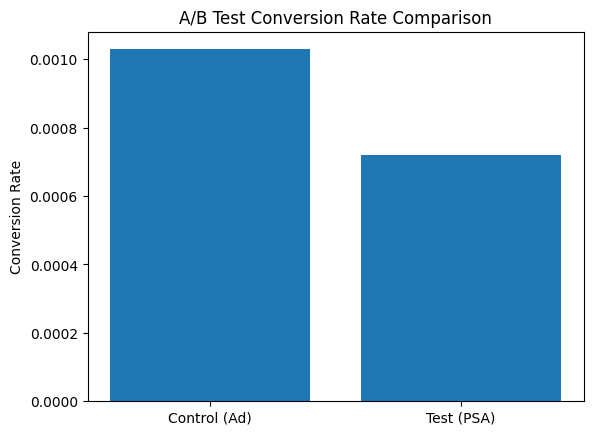

In [ ]:
import matplotlib.pyplot as plt

labels = ['Control (Ad)', 'Test (PSA)']
rates = [control_rate, test_rate]

plt.bar(labels, rates)
plt.ylabel("Conversion Rate")
plt.title("A/B Test Conversion Rate Comparison")
plt.show()

In [ ]:
if test_rate > control_rate:
    print("Test campaign performs better and should be adopted.")
else:
    print("Control campaign performs better and should continue.")

Control campaign performs better and should continue.


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

conversions = [control['converted'].sum(), test['converted'].sum()]
visitors = [control['total ads'].sum(), test['total ads'].sum()]

z_stat, p_value = proportions_ztest(conversions, visitors)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: 7.228637767350958
P Value: 4.878627648760414e-13


In [ ]:
#If p-value < 0.05 → statistically significant difference